In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
df = pd.read_csv("data/AB_NYC_2019.csv")
df.shape

(48895, 16)

In [4]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [6]:
import os
os.makedirs("outputs", exist_ok=True)


In [7]:
dtypes = df.dtypes

In [8]:
null_counts = df.isnull().sum()


In [9]:
null_pct = df.isnull().mean() * 100

In [10]:
cardinality = df.nunique()

In [11]:
null_counts 

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [12]:
sample_values = {col: df[col].dropna().iloc[0] for col in df.columns}


In [13]:
quality_report = pd.DataFrame({
    "dtype": dtypes,
    "null_count": null_counts,
    "null_pct": null_pct,
    "cardinality": cardinality,
    "sample_value": sample_values,
})
quality_report


,dtype,null_count,null_pct,cardinality,sample_value
id,int64,0,0.000000,48895,2539
name,str,16,0.032723,47905,Clean & quiet apt home by the park
host_id,int64,0,0.000000,37457,2787
host_name,str,21,0.042949,11452,John
neighbourhood_group,str,0,0.000000,5,Brooklyn
neighbourhood,str,0,0.000000,221,Kensington
latitude,float64,0,0.000000,19048,40.64749
longitude,float64,0,0.000000,14718,-73.97237
room_type,str,0,0.000000,3,Private room
price,int64,0,0.000000,674,149


In [14]:
quality_report.to_csv("outputs/data_quality_report.csv")


In [15]:
import matplotlib.pyplot as plt


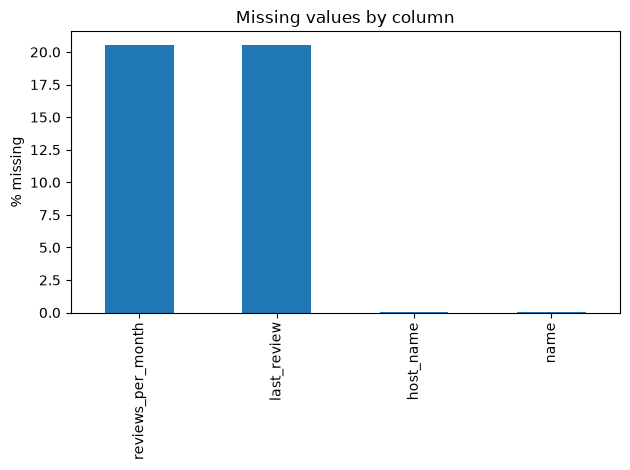

In [16]:
null_pct[null_pct > 0].sort_values(ascending=False).plot(kind="bar")
plt.ylabel("% missing")
plt.title("Missing values by column")
plt.tight_layout()
plt.savefig("outputs/01_missing_values.png")
plt.show()


In [17]:
df.duplicated().sum()


np.int64(0)

In [18]:
df = df.drop_duplicates()
df.shape



(48895, 16)

In [19]:
null_pct_now = df.isnull().mean() * 100
cols_to_drop = null_pct_now[null_pct_now > 60].index
cols_to_drop


Index([], dtype='str')

In [20]:
df = df.drop(columns=cols_to_drop)
df.shape



(48895, 16)

In [21]:
df['last_review'] = pd.to_datetime(df['last_review'])
df['last_review'].dtype


dtype('<M8[us]')

In [22]:
numeric_cols = df.select_dtypes(include="number").columns
categorical_cols = df.select_dtypes(include="object").columns
numeric_cols, categorical_cols


C:\Users\godwo\AppData\Local\Temp\ipykernel_18584\2618262617.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


(Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
        'number_of_reviews', 'reviews_per_month',
        'calculated_host_listings_count', 'availability_365'],
       dtype='str'),
 Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
        'room_type'],
       dtype='str'))

In [23]:
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df[categorical_cols] = df[categorical_cols].fillna("Unknown")
df.isnull().sum()


id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [24]:
for col in categorical_cols:
    df[col] = df[col].str.strip()


In [25]:
df['neighbourhood_group'].unique()


<StringArray>
['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx']
Length: 5, dtype: str

In [26]:
df.columns


Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [27]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns


Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [28]:
outlier_cols = [c for c in numeric_cols if c not in ['id', 'host_id', 'latitude', 'longitude']]
outlier_cols


['price',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [29]:
Q1 = df[outlier_cols].quantile(0.25)
Q3 = df[outlier_cols].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_counts = ((df[outlier_cols] < lower) | (df[outlier_cols] > upper)).sum()
outlier_counts


price                             2972
minimum_nights                    6607
number_of_reviews                 6021
reviews_per_month                 4103
calculated_host_listings_count    7081
availability_365                     0
dtype: int64

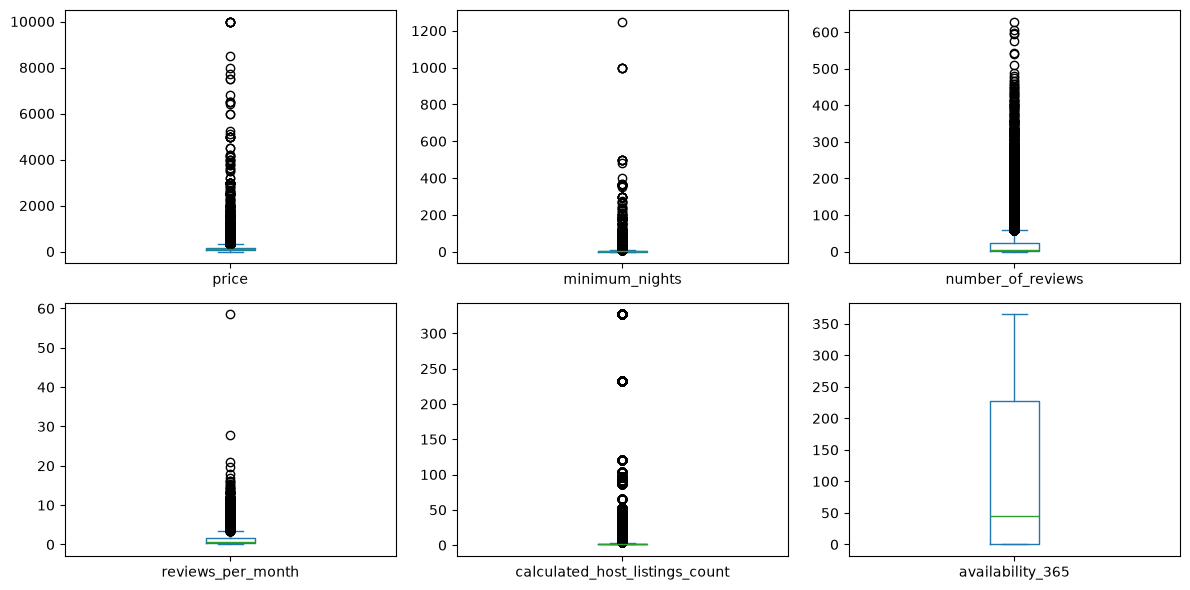

In [30]:
df[outlier_cols].plot(kind="box", subplots=True, layout=(2, 3), figsize=(12, 6))
plt.tight_layout()
plt.savefig("outputs/02_outliers_before.png")
plt.show()


In [31]:
outlier_report = pd.DataFrame({
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "lower_fence": lower,
    "upper_fence": upper,
    "outlier_count": outlier_counts,
})
outlier_report.to_csv("outputs/outlier_report.csv")
outlier_report


,Q1,Q3,IQR,lower_fence,upper_fence,outlier_count
price,69.00,175.00,106.0,-90.00,334.00,2972
minimum_nights,1.00,5.00,4.0,-5.00,11.00,6607
number_of_reviews,1.00,24.00,23.0,-33.50,58.50,6021
reviews_per_month,0.28,1.58,1.3,-1.67,3.53,4103
calculated_host_listings_count,1.00,2.00,1.0,-0.50,3.50,7081
availability_365,0.00,227.00,227.0,-340.50,567.50,0


In [32]:
((df[outlier_cols] < lower) | (df[outlier_cols] > upper)).sum()


price                             2972
minimum_nights                    6607
number_of_reviews                 6021
reviews_per_month                 4103
calculated_host_listings_count    7081
availability_365                     0
dtype: int64

In [33]:
df[outlier_cols] = df[outlier_cols].clip(lower=lower, upper=upper, axis=1)


In [34]:
((df[outlier_cols] < lower) | (df[outlier_cols] > upper)).sum()


price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

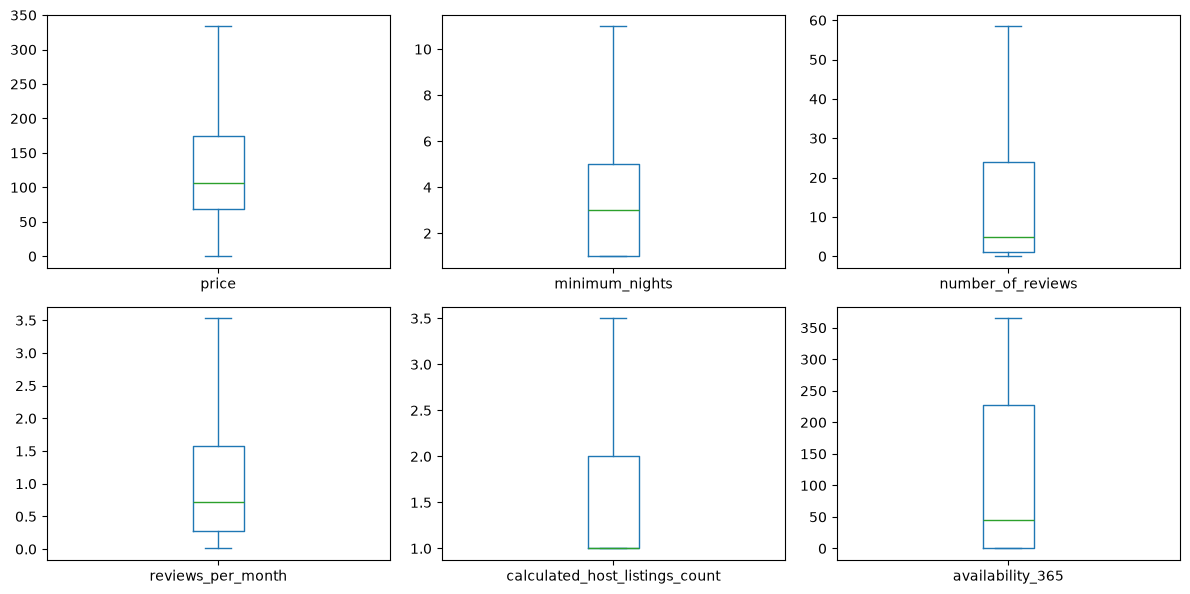

In [35]:
df[outlier_cols].plot(kind="box", subplots=True, layout=(2, 3), figsize=(12, 6))
plt.tight_layout()
plt.savefig("outputs/03_outliers_after.png")
plt.show()


In [36]:
df.to_csv("outputs/cleaned_data.csv", index=False)


In [37]:
summary = pd.DataFrame({
    "before": {
        "rows": 48895,
        "columns": 16,
        "duplicate_rows": 0,
        "missing_cells": 16 + 21 + 10052 + 10052,
    },
    "after": {
        "rows": df.shape[0],
        "columns": df.shape[1],
        "duplicate_rows": df.duplicated().sum(),
        "missing_cells": df.isnull().sum().sum(),
    },
})
summary


,before,after
rows,48895,48895
columns,16,16
duplicate_rows,0,0
missing_cells,20141,10052
